## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Evaluation BertMorphTaggerHomonymFull**](#hindamine_homonyms)
3. [**Results BertMorphTaggerV2HomonymFull**](#tulemused_homonyms)
4. [**Evaluation BertMorphTaggerHomonymFullFinetune**](#hindamine_homonyms_finetune)
5. [**Results BertMorphTaggerV2HomonymFullFinetune**](#tulemused_homonyms_finetune)

[end](#end)


### Conclusive evaluation results for the model

### Macro average metrics

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model                                                     | Accuracy | Precision | Recall | F1-score |
| --------------------------------------------------------- | -------: | --------: | -----: | -------: |
| BertMorphTaggerV2HomonymFull                              |   99.91% |    99.95% | 99.90% |   99.92% |
| BertMorphTaggerV2HomonymFull (lenient)                    |   99.91% |    99.95% | 99.90% |   99.92% |
| BertMorphTaggerV2HomonymFull (lenient, no others)         |   99.91% |    99.95% | 99.90% |   99.92% |
| BertMorphTaggerV2HomonymFullFinetune                      |   99.94% |    79.78% | 79.96% |   79.87% |
| BertMorphTaggerV2HomonymFullFinetune (lenient)            |   99.95% |    99.72% | 99.96% |   99.84% |
| BertMorphTaggerV2HomonymFullFinetune (lenient, no others) |   99.95% |    99.72% | 99.96% |   99.84% |

For both models, predictions outside the set of possible labels: **0/7886 (0.00%)**


### Imports


In [1]:
print("Test")

Test


In [2]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [3]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [4]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [5]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


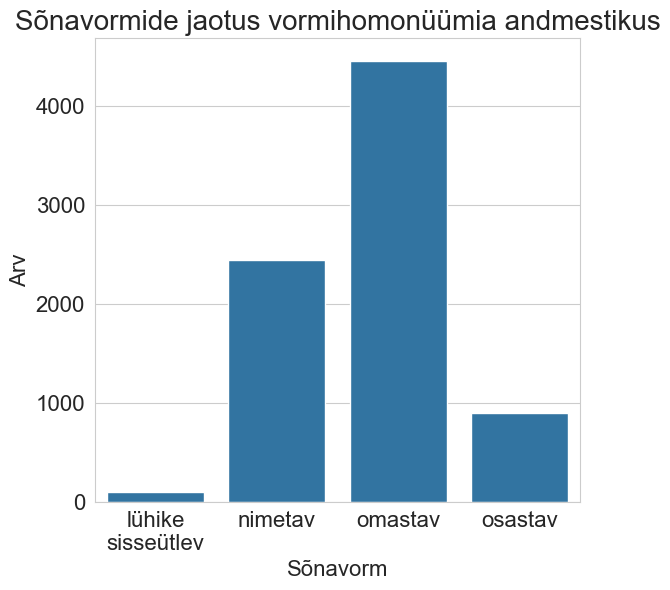

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_31564\215362590.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


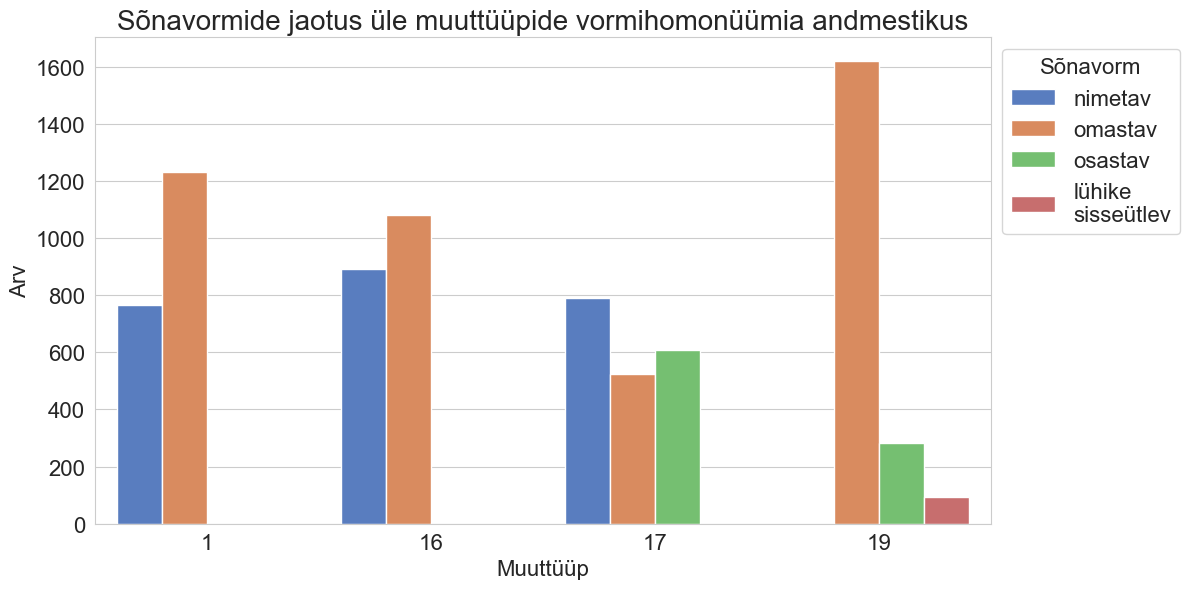

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike\nsisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Sõnavormide jaotus vormihomonüümia andmestikus", fontsize=20)
plt.xlabel("Sõnavorm", fontsize=16)
plt.ylabel("Arv", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Sõnavormide jaotus üle muuttüüpide vormihomonüümia andmestikus", fontsize=20)
plt.xlabel("Muuttüüp", fontsize=16)
plt.ylabel("Arv", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(
    title="Sõnavorm",
    bbox_to_anchor=(1, 1),
    loc="upper left",
    fontsize=16,
    title_fontsize=16,
)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='hindamine_homonyms'></a>


### Evaluation BertMorphTaggerV2HomonymFull


In [6]:
# Define model to use for annotation
model_path = "../models/NER_mudel_v2_homonym_full/"
model_name = "BertMorphTaggerV2HomonymFull"
df_output_csv_path = str(
    HOMONYMS_DIRS["annotations"] / "homonyms_annotations_Bert_morph_V2_homonym_full.csv"
)

In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_path,
    output_csv_path=df_output_csv_path,
    progress_desc="Evaluating BertMorphTaggerV2_homonym_full on homonyms dataset",
)

Evaluating BertMorphTaggerV2_homonym_full on homonyms dataset: 100%|██████████| 7886/7886 [07:17<00:00, 18.03it/s]


<a id='tulemused_homonyms'></a>


### Results BertMorphTaggerV2HomonymFull


In [7]:
# Load results dataframe
results_df = pd.read_csv(
    df_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

# Count how many unique classes were predicted outside of the set of possible classes
possible_classes = set(results_df_split["true_case"].unique())
predicted_classes = set(results_df_split["pred_case"].unique())
predicted_outside_possible = predicted_classes - possible_classes
print(
    f"\nPredicted classes outside of possible set: {predicted_outside_possible} (count: {len(predicted_outside_possible)})"
)

BertMorphTaggerV2HomonymFull results:
Overall results
Accuracy:  99.91%
Precision: 99.95%
Recall:    99.90%
F1-score:  99.92%

BertMorphTaggerV2HomonymFull results (lenient):
Overall results
Accuracy:  99.91%
Precision: 99.95%
Recall:    99.90%
F1-score:  99.92%

BertMorphTaggerV2HomonymFull results (lenient, excluding 'other'):
Overall results
Accuracy:  99.91%
Precision: 99.95%
Recall:    99.90%
F1-score:  99.92%

Number of "other" cases: 0 out of 7886 (0.00%)

Predicted classes outside of possible set: set() (count: 0)


In [5]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2HomonymFull classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       1.00      1.00      1.00        94
        sg g       1.00      1.00      1.00      4457
        sg n       1.00      1.00      1.00      2445
        sg p       1.00      1.00      1.00       890

    accuracy                           1.00      7886
   macro avg       1.00      1.00      1.00      7886
weighted avg       1.00      1.00      1.00      7886



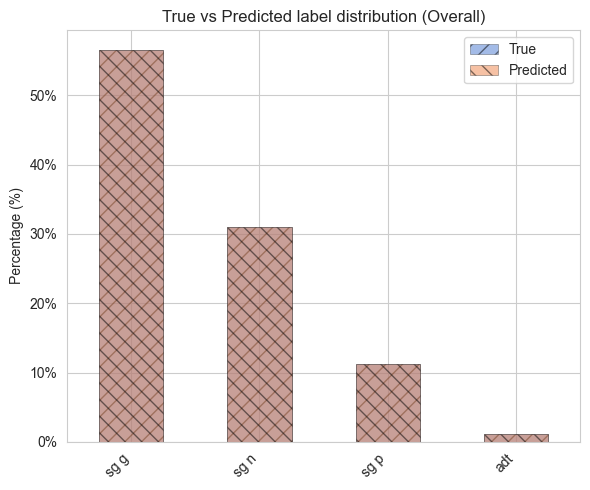

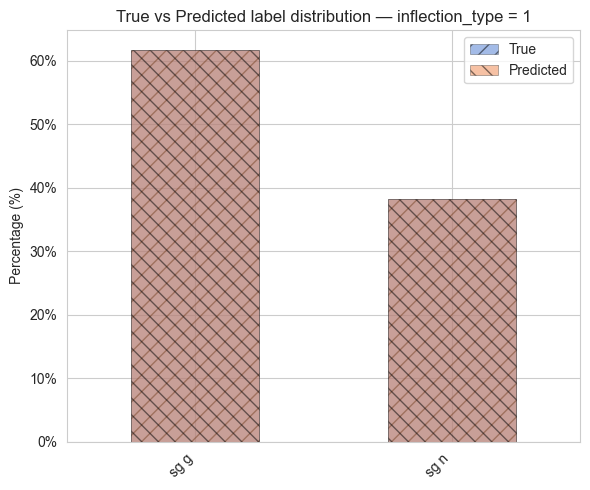

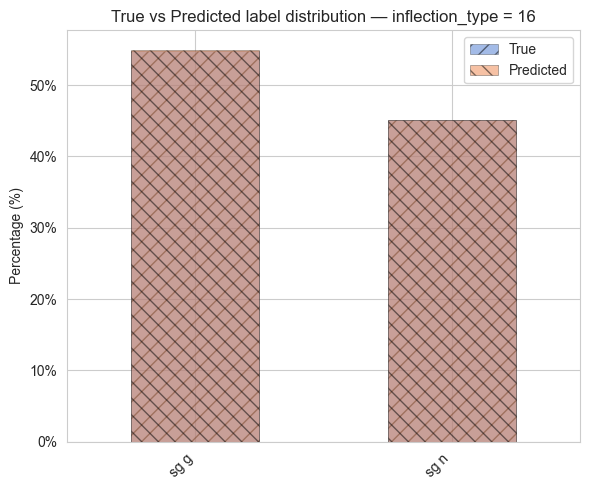

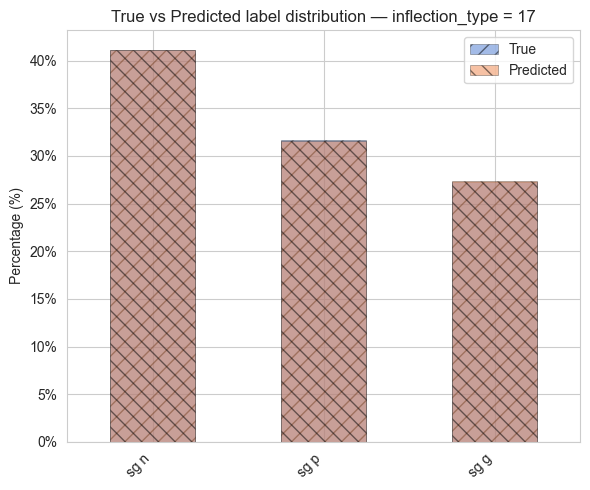

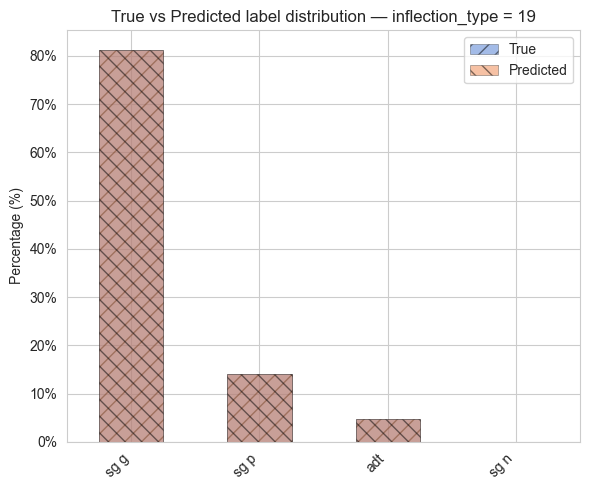

In [6]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

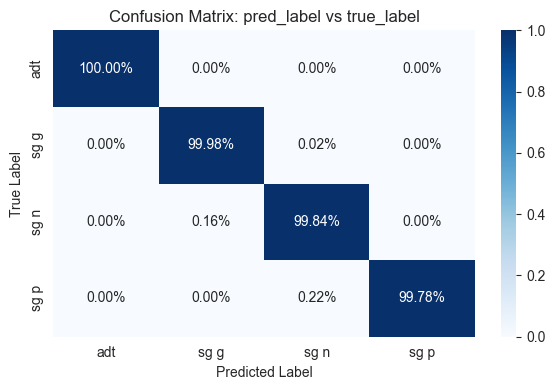

In [7]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

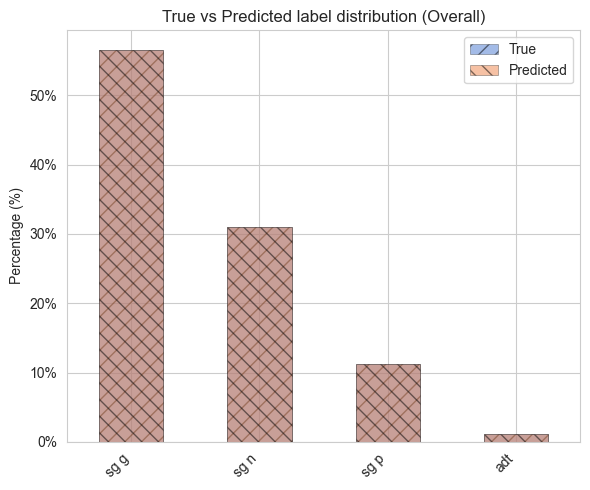

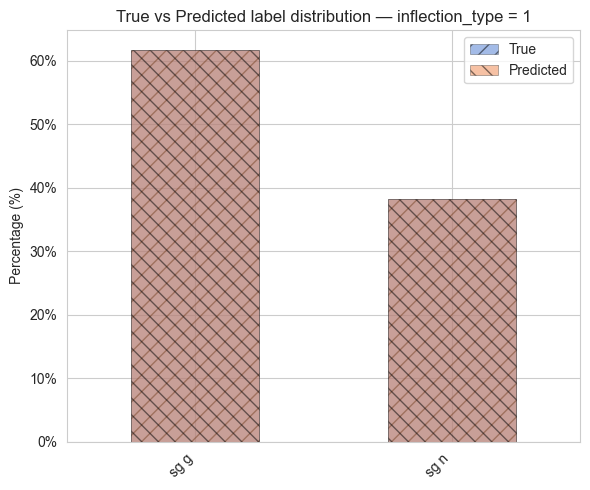

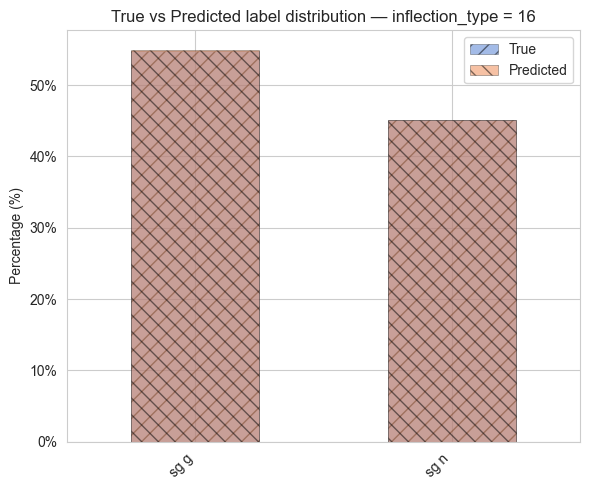

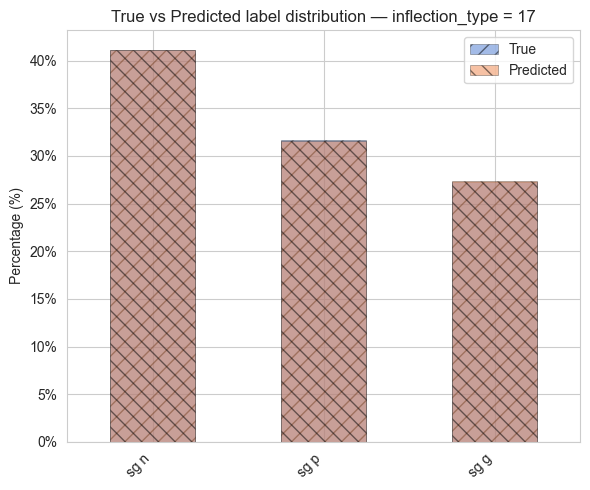

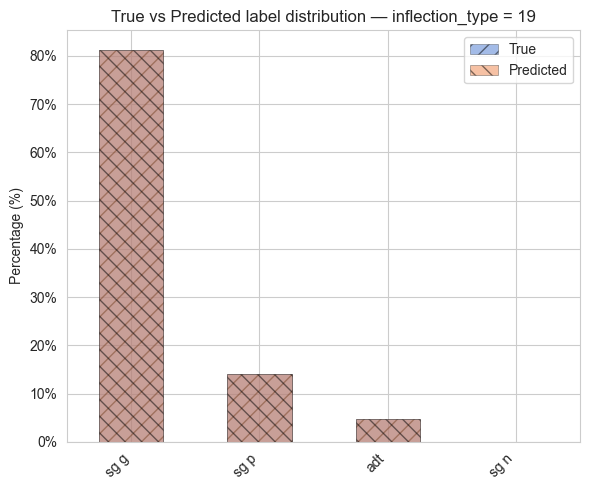

In [8]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

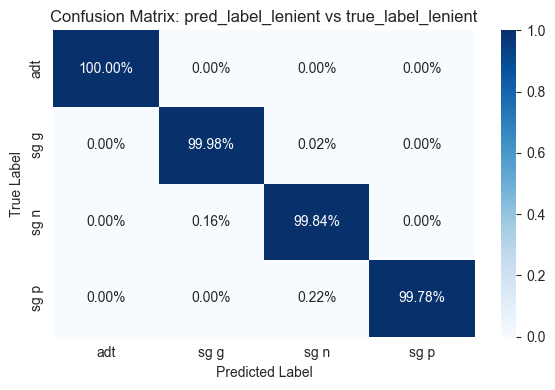

In [9]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

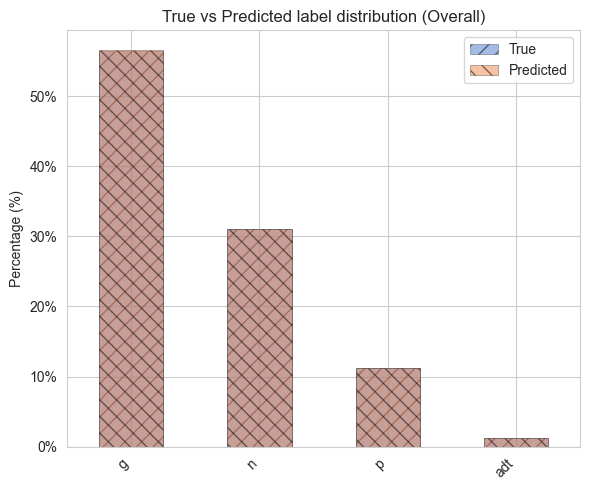

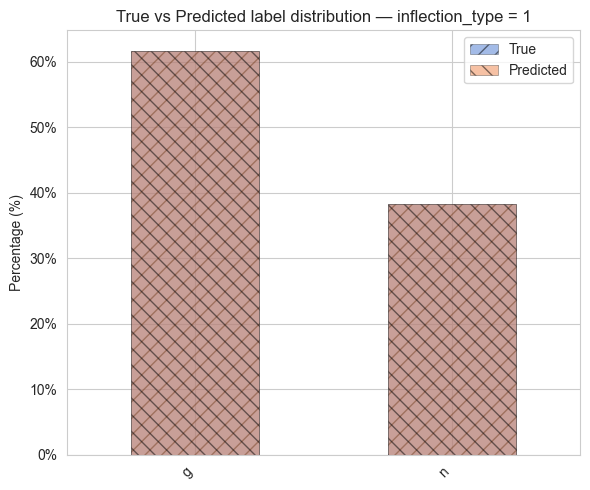

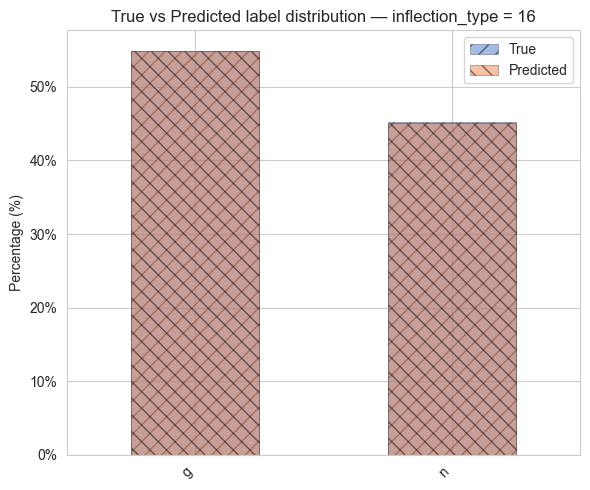

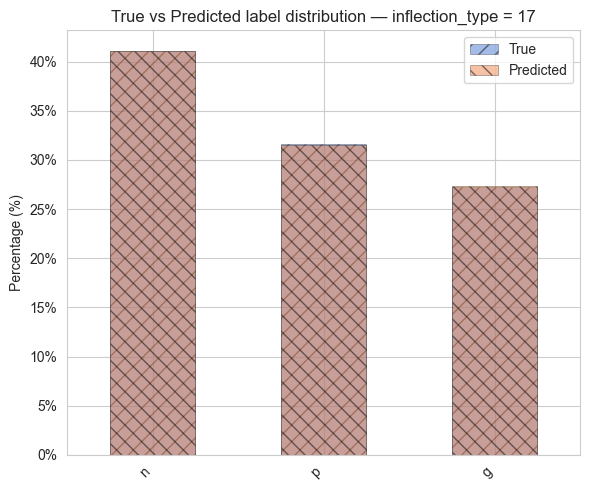

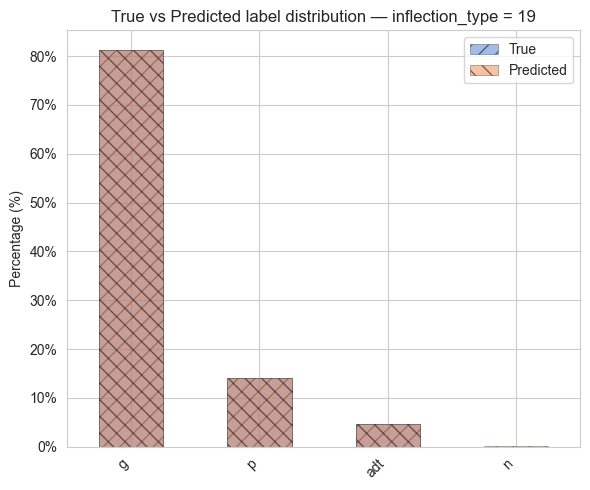

In [10]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

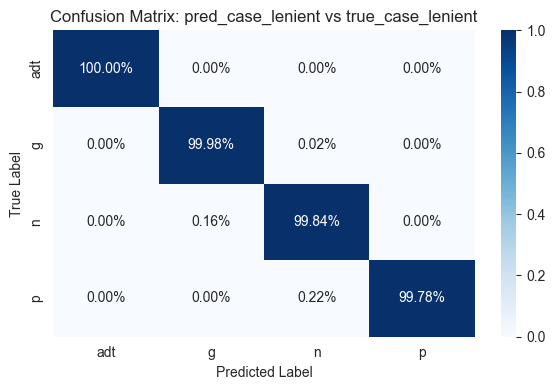

In [11]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

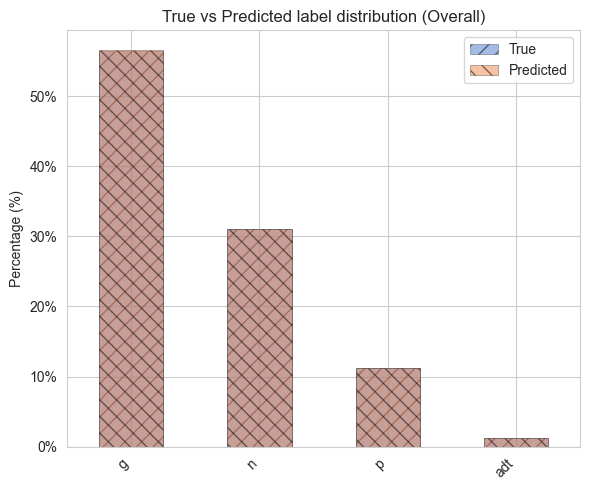

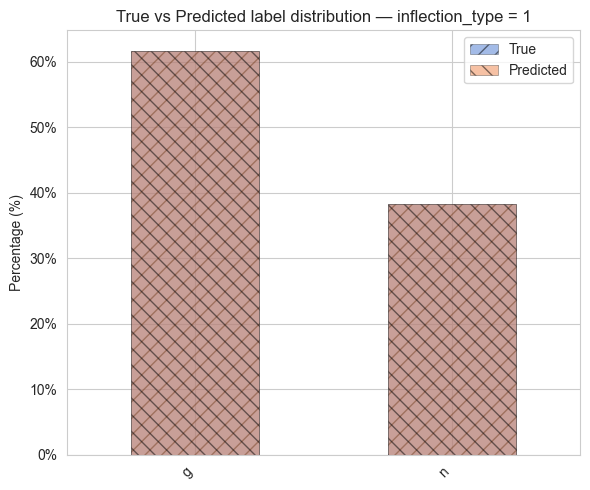

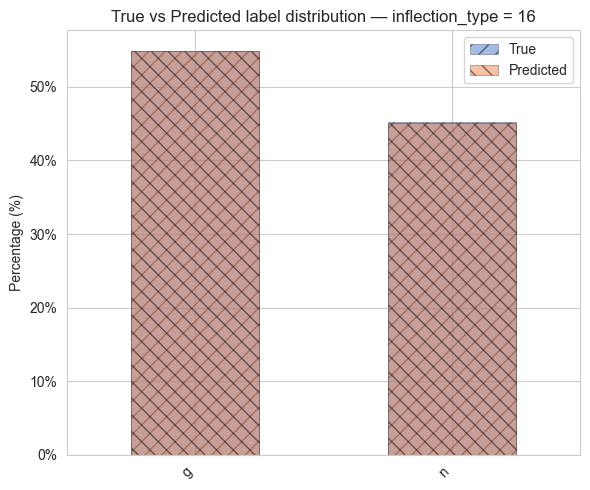

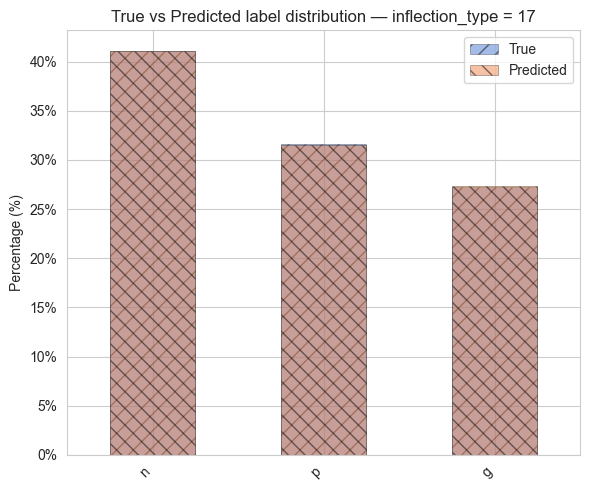

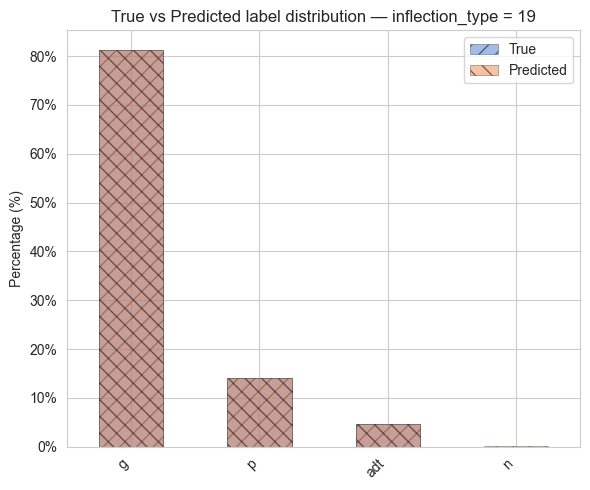

In [12]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

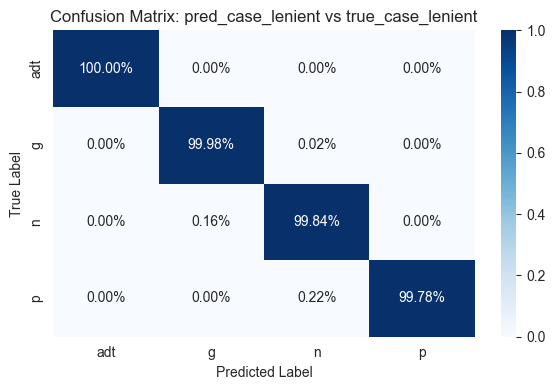

In [13]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [14]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2HomonymFull results per inflection type:
inflection_type=1
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-score:  100.00%
inflection_type=16
Accuracy:  99.90%
Precision: 99.90%
Recall:    99.90%
F1-score:  99.90%
inflection_type=17
Accuracy:  99.79%
Precision: 99.79%
Recall:    99.79%
F1-score:  99.79%
inflection_type=19
Accuracy:  99.95%
Precision: 100.00%
Recall:    99.95%
F1-score:  99.97%


In [15]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2HomonymFull classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1232
        sg n       1.00      1.00      1.00       764

    accuracy                           1.00      1996
   macro avg       1.00      1.00      1.00      1996
weighted avg       1.00      1.00      1.00      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1080
        sg n       1.00      1.00      1.00       890

    accuracy                           1.00      1970
   macro avg       1.00      1.00      1.00      1970
weighted avg       1.00      1.00      1.00      1970

inflection_type=17 - Classification Report
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00       524
        sg n       1.00      1.00   

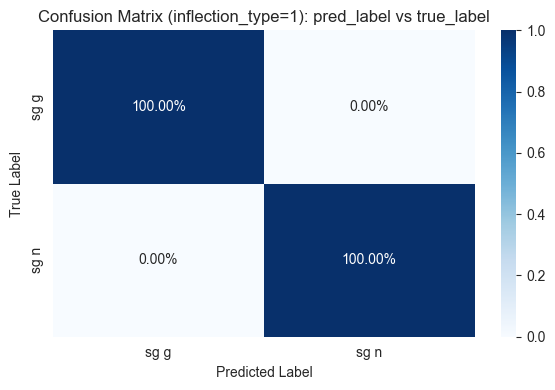

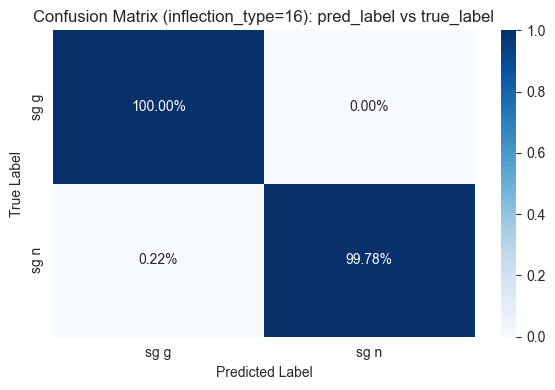

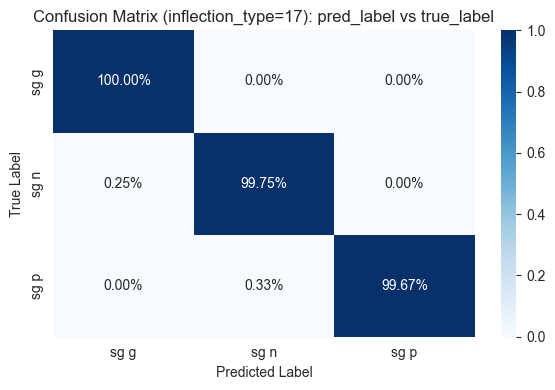

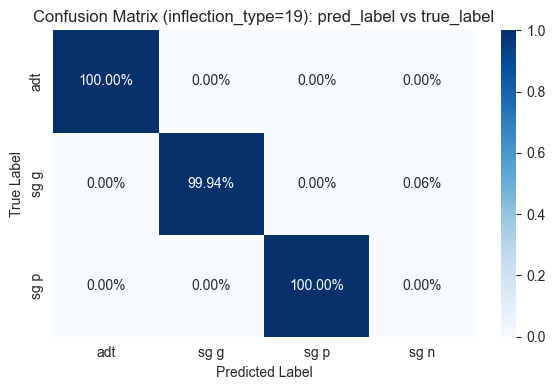

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      1       0.05              True              0
Sum of true labels count: 1996


In [16]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

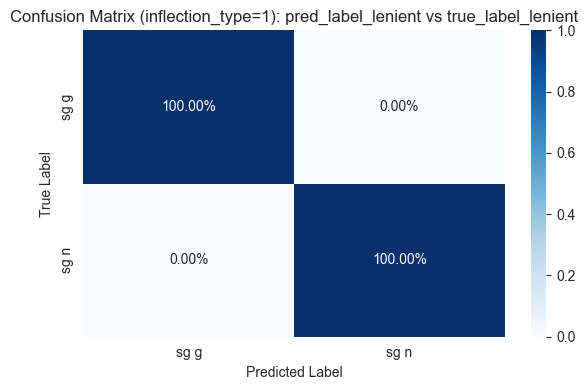

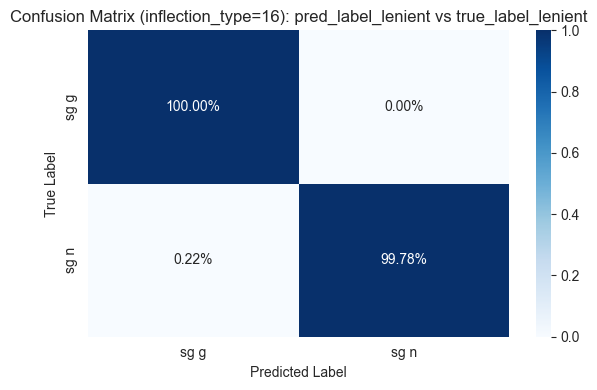

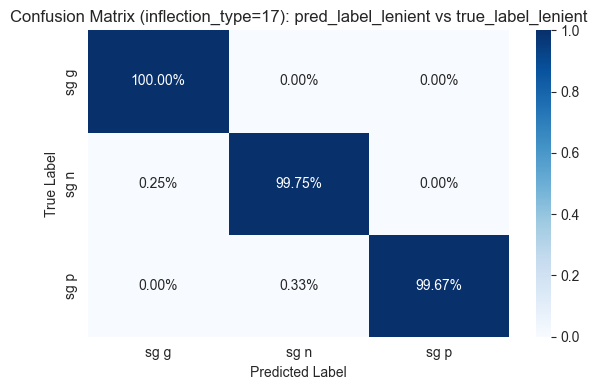

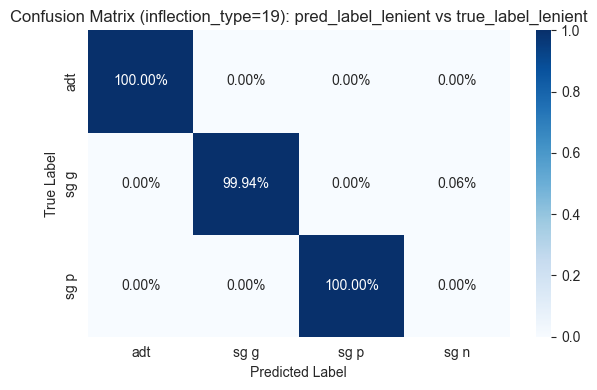

Confusion Matrix (inflection_type=19): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      1       0.05              True              0
Sum of true labels count: 1996


In [17]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

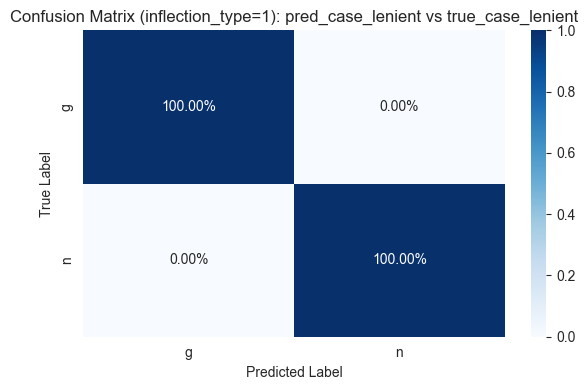

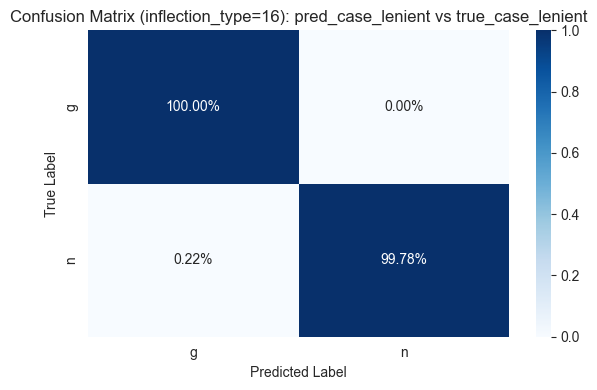

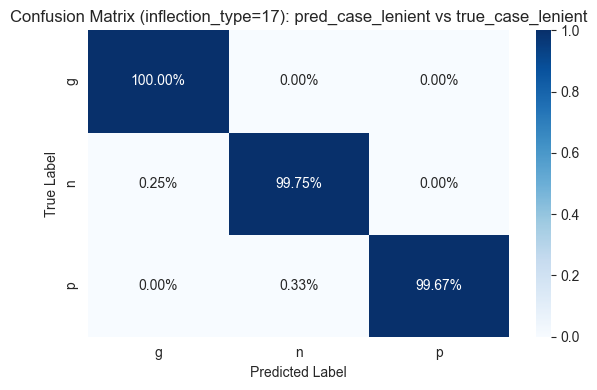

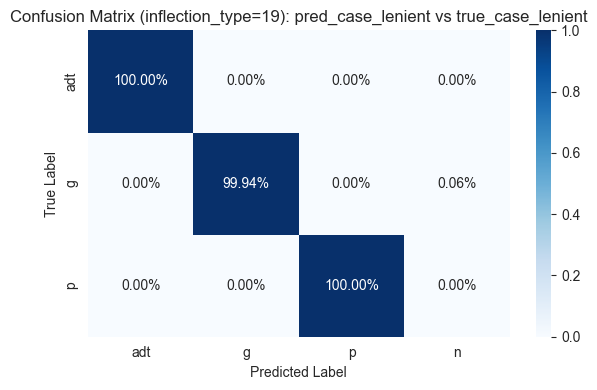

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      1       0.05              True              0
Sum of true labels count: 1996


In [18]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

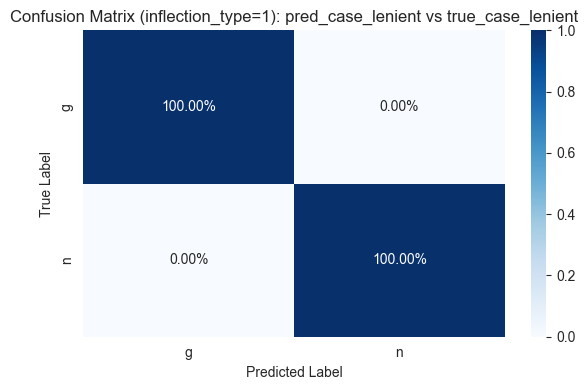

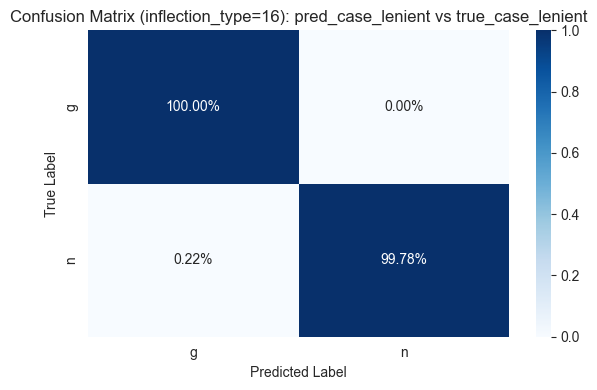

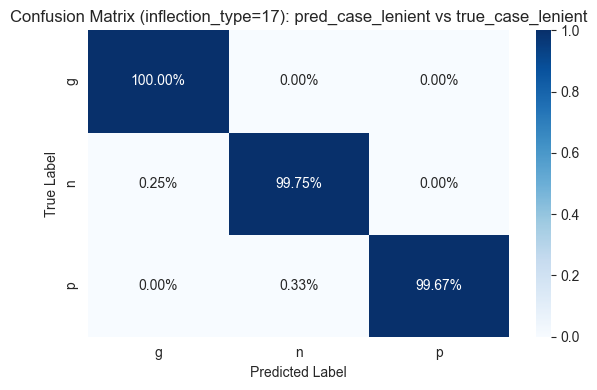

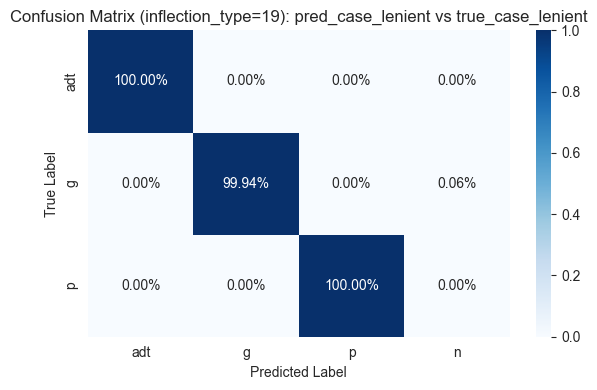

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      1       0.05              True              0
Sum of true labels count: 1996


In [19]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

<a id='hindamine_homonyms_finetune'></a>


### Evaluation BertMorphTaggerV2HomonymFullFinetune


In [8]:
# Define model to use for annotation
model_path = "../models/NER_mudel_v2_homonym_full_finetune/"
model_name = "BertMorphTaggerV2HomonymFullFinetune"
df_finetuned_output_csv_path = str(
    HOMONYMS_DIRS["annotations"]
    / "homonyms_annotations_Bert_morph_V2_homonym_full_finetune.csv"
)

In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_path,
    output_csv_path=df_finetuned_output_csv_path,
    progress_desc="Evaluating BertMorphTaggerV2_homonym_full_finetune on homonyms dataset",
)

Evaluating BertMorphTaggerV2_homonym_full_finetune on homonyms dataset: 100%|██████████| 7886/7886 [07:07<00:00, 18.43it/s]


<a id='tulemused_homonyms_finetune'></a>


### Results BertMorphTaggerV2HomonymFullFinetune


In [9]:
# Load results dataframe
results_df = pd.read_csv(
    df_finetuned_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

# Count how many unique classes were predicted outside of the set of possible classes
possible_classes = set(results_df_split["true_case"].unique())
predicted_classes = set(results_df_split["pred_case"].unique())
predicted_outside_possible = predicted_classes - possible_classes
print(
    f"\nPredicted classes outside of possible set: {predicted_outside_possible} (count: {len(predicted_outside_possible)})"
)

BertMorphTaggerV2HomonymFullFinetune results:
Overall results
Accuracy:  99.94%
Precision: 79.78%
Recall:    79.96%
F1-score:  79.87%

BertMorphTaggerV2HomonymFullFinetune results (lenient):
Overall results
Accuracy:  99.95%
Precision: 99.72%
Recall:    99.96%
F1-score:  99.84%

BertMorphTaggerV2HomonymFullFinetune results (lenient, excluding 'other'):
Overall results
Accuracy:  99.95%
Precision: 99.72%
Recall:    99.96%
F1-score:  99.84%

Number of "other" cases: 0 out of 7886 (0.00%)

Predicted classes outside of possible set: set() (count: 0)


In [22]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2HomonymFullFinetune classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       0.99      1.00      0.99        94
        pl g       0.00      0.00      0.00         0
        sg g       1.00      1.00      1.00      4457
        sg n       1.00      1.00      1.00      2445
        sg p       1.00      1.00      1.00       890

    accuracy                           1.00      7886
   macro avg       0.80      0.80      0.80      7886
weighted avg       1.00      1.00      1.00      7886



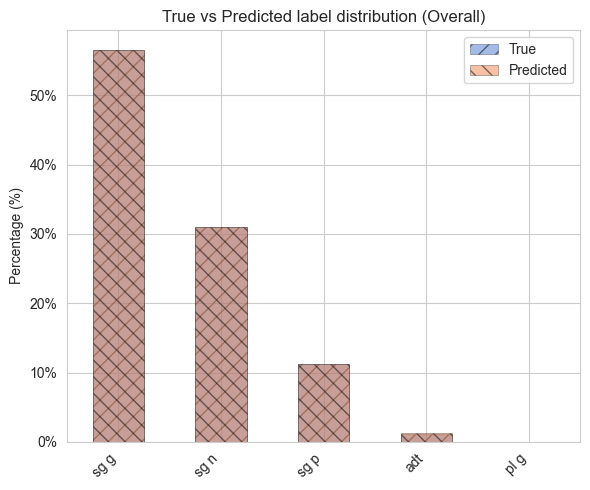

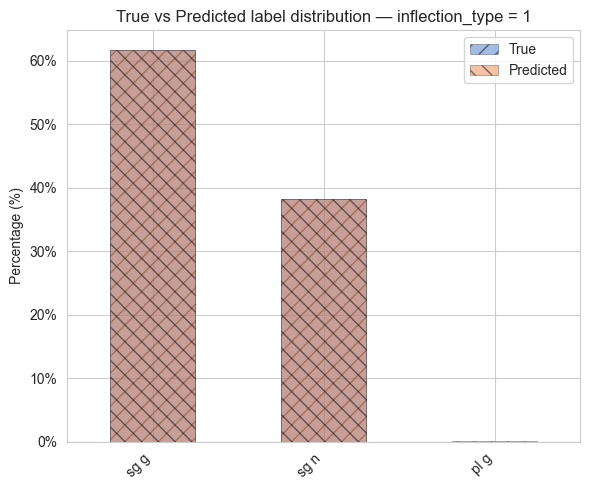

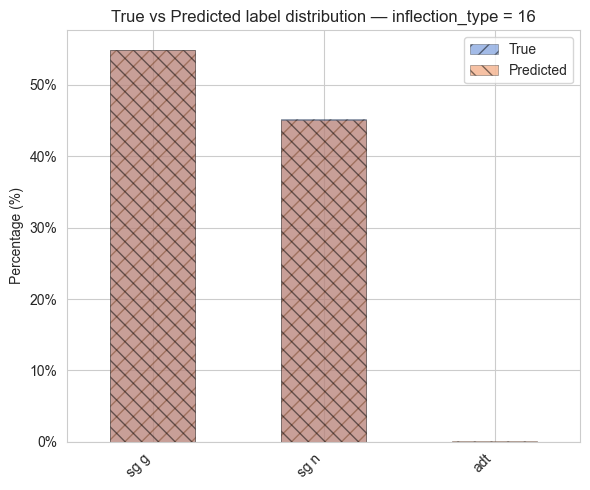

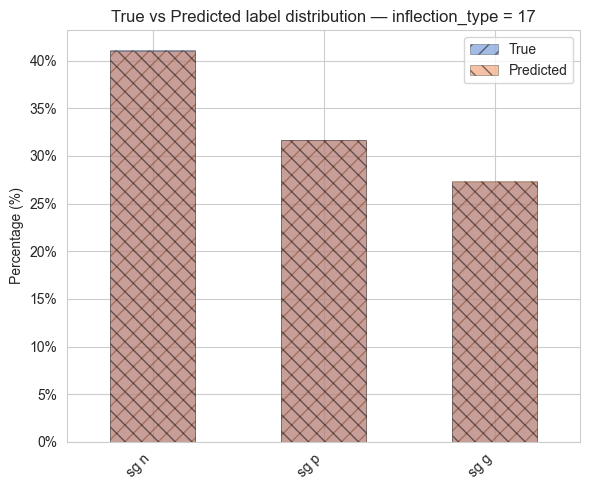

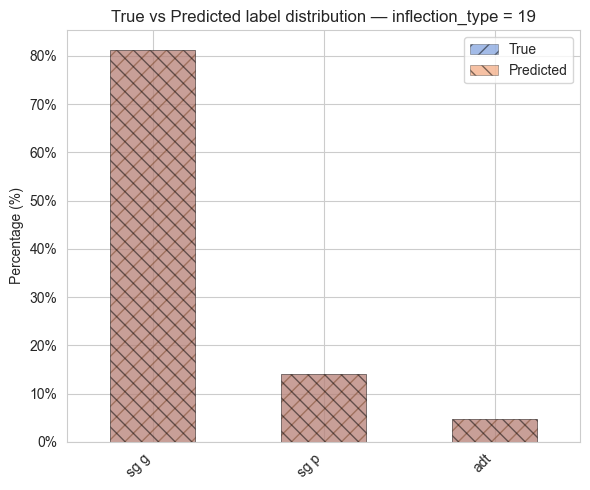

In [23]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

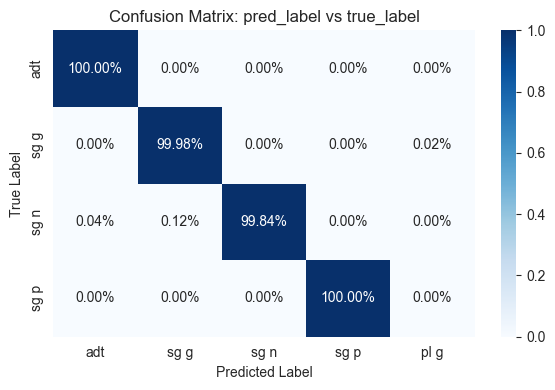

Confusion Matrix: pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl g      1       0.01              True              0
Sum of true labels count: 7886


In [24]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

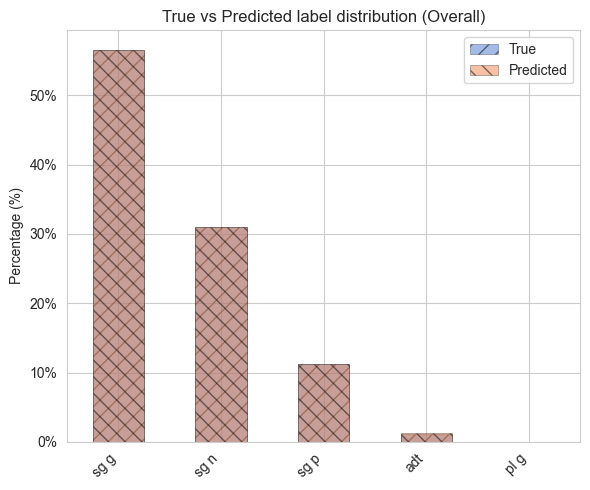

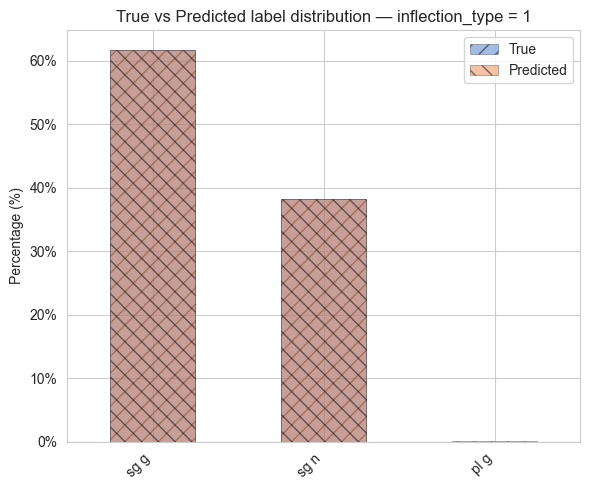

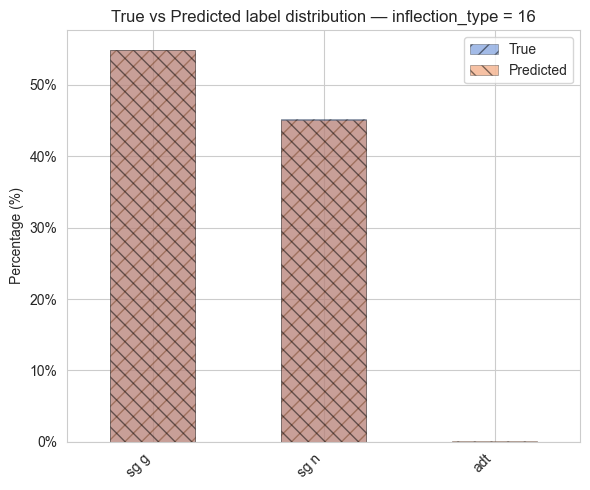

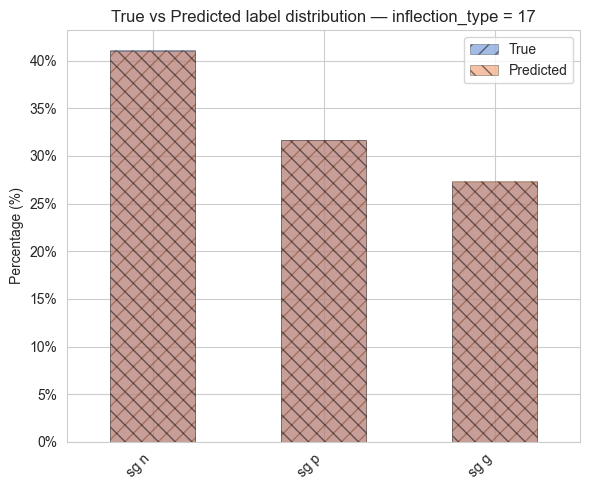

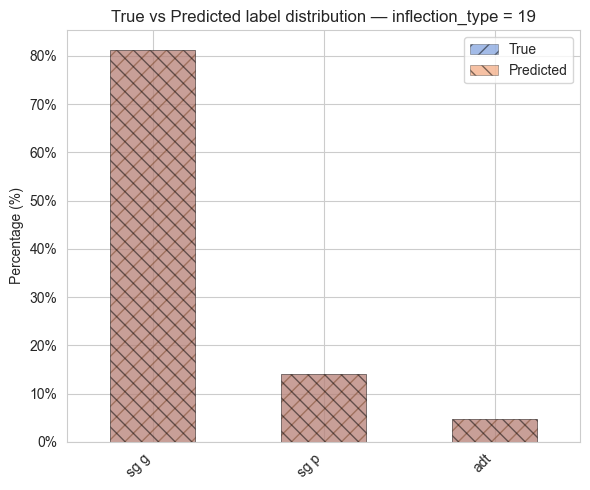

In [25]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

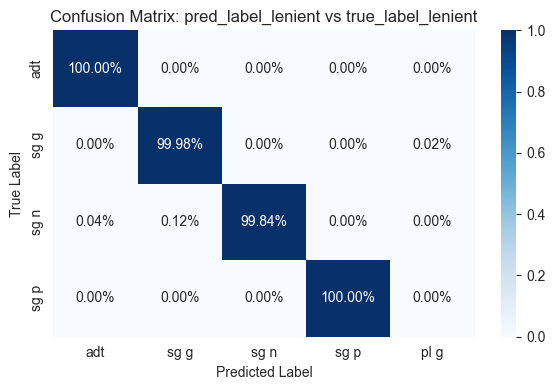

Confusion Matrix: pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl g      1       0.01              True              0
Sum of true labels count: 7886


In [26]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

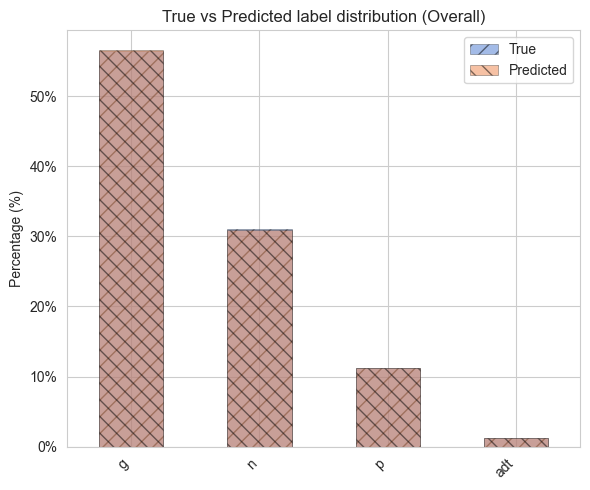

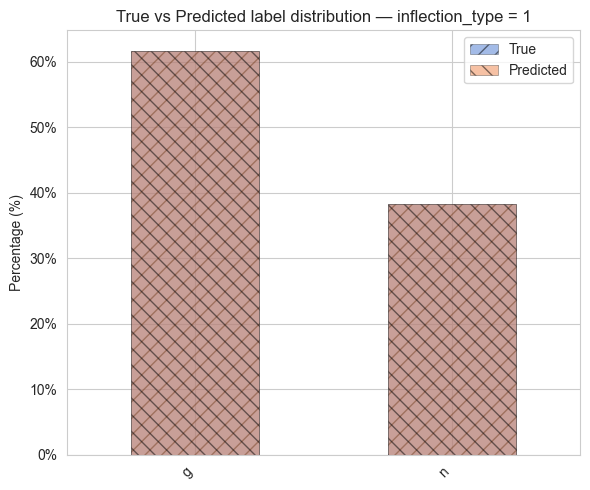

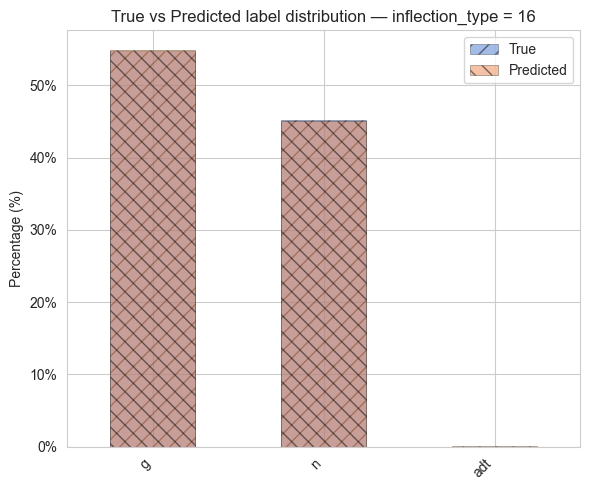

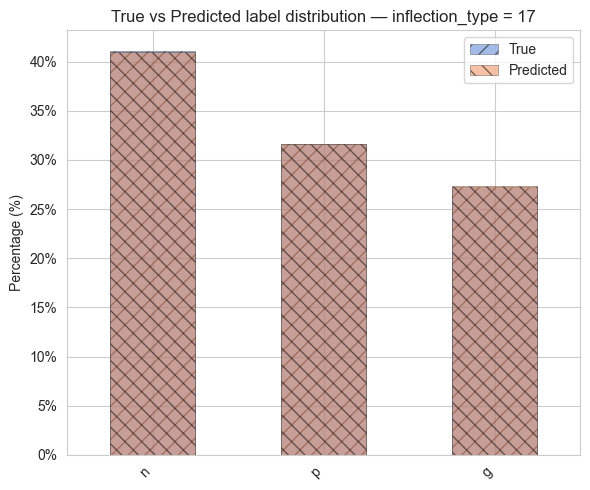

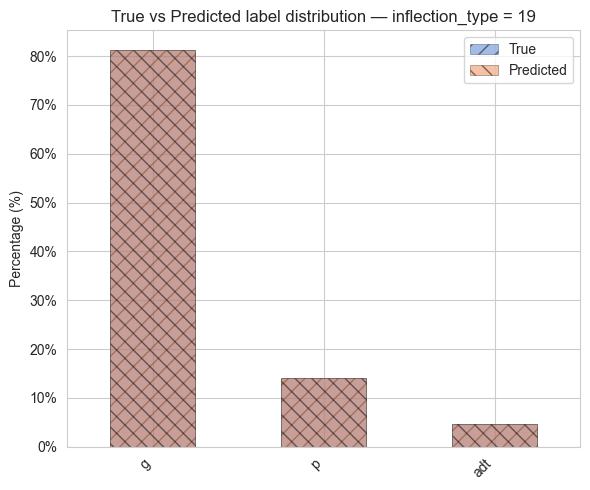

In [27]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

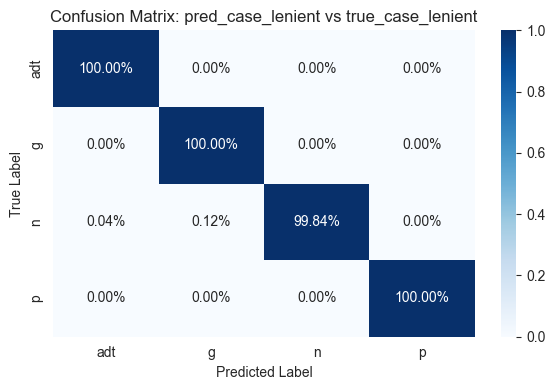

In [28]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

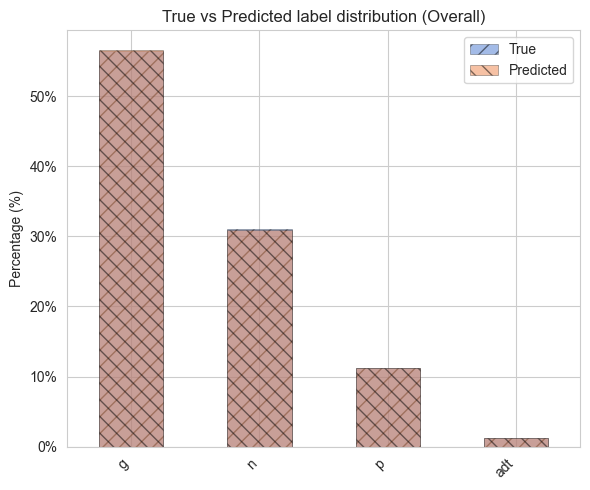

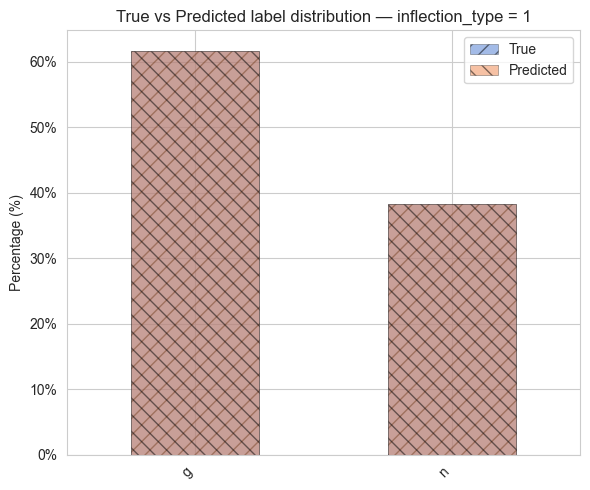

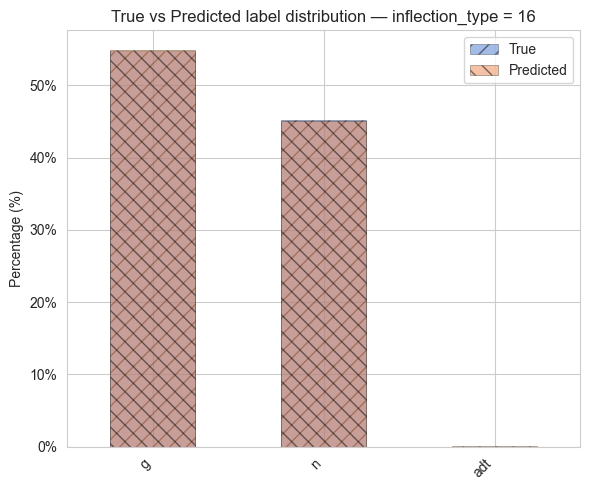

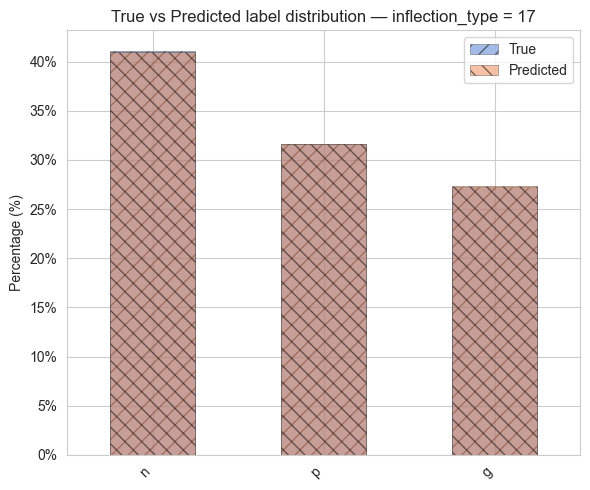

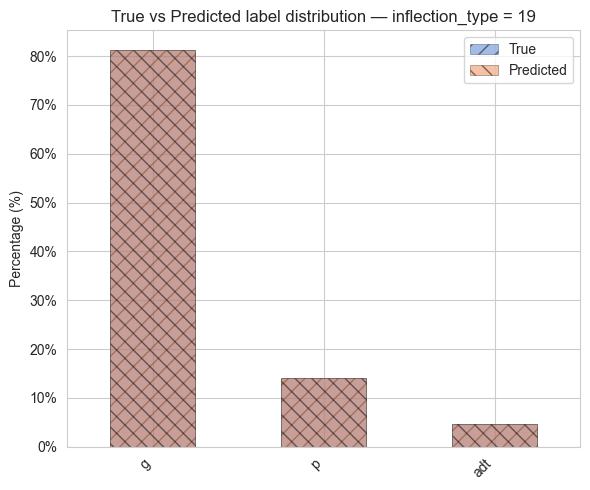

In [29]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

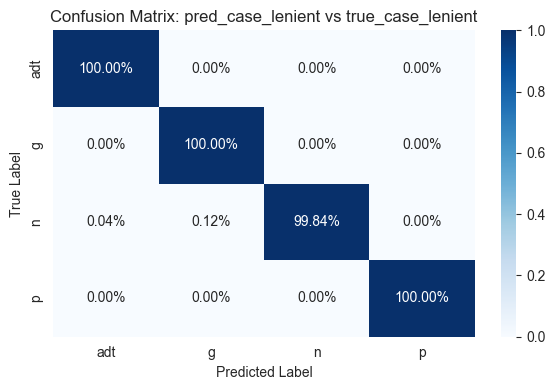

In [30]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [31]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2HomonymFullFinetune results per inflection type:
inflection_type=1
Accuracy:  99.95%
Precision: 100.00%
Recall:    99.95%
F1-score:  99.97%
inflection_type=16
Accuracy:  99.90%
Precision: 99.95%
Recall:    99.90%
F1-score:  99.92%
inflection_type=17
Accuracy:  99.90%
Precision: 99.90%
Recall:    99.90%
F1-score:  99.90%
inflection_type=19
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-score:  100.00%


In [32]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2HomonymFullFinetune classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

        pl g       0.00      0.00      0.00         0
        sg g       1.00      1.00      1.00      1232
        sg n       1.00      1.00      1.00       764

    accuracy                           1.00      1996
   macro avg       0.67      0.67      0.67      1996
weighted avg       1.00      1.00      1.00      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
        sg g       1.00      1.00      1.00      1080
        sg n       1.00      1.00      1.00       890

    accuracy                           1.00      1970
   macro avg       0.67      0.67      0.67      1970
weighted avg       1.00      1.00      1.00      1970

inflection_type=17 - Classification Report
              precision    re

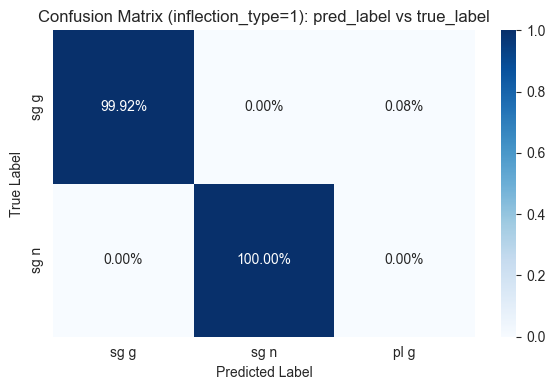

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl g      1       0.05              True              0
Sum of true labels count: 1996


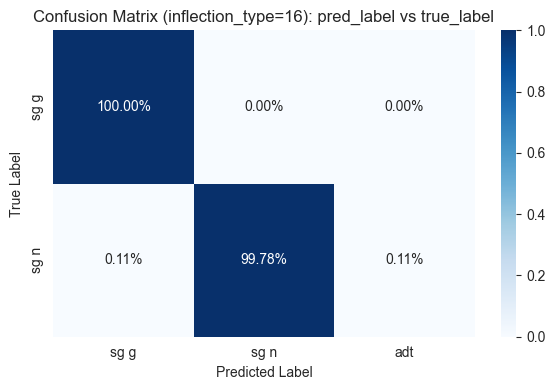

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1970


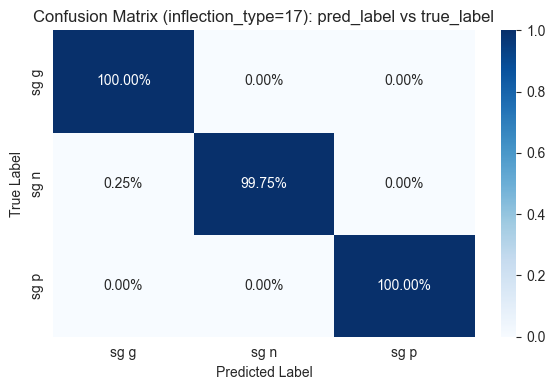

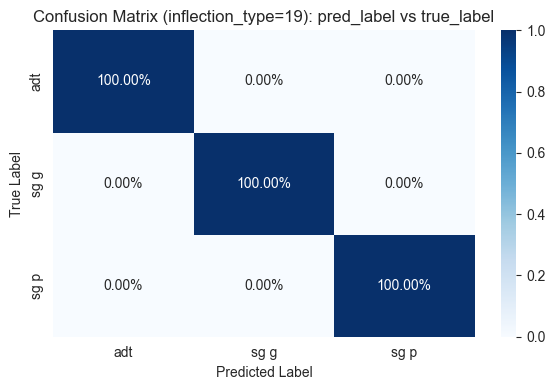

In [33]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

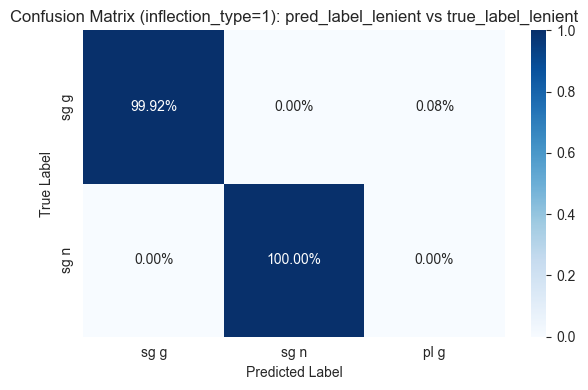

Confusion Matrix (inflection_type=1): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl g      1       0.05              True              0
Sum of true labels count: 1996


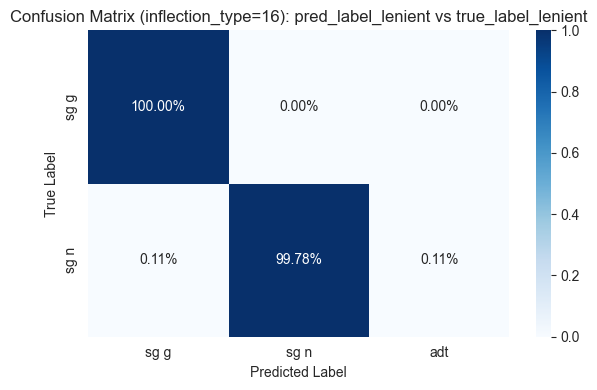

Confusion Matrix (inflection_type=16): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1970


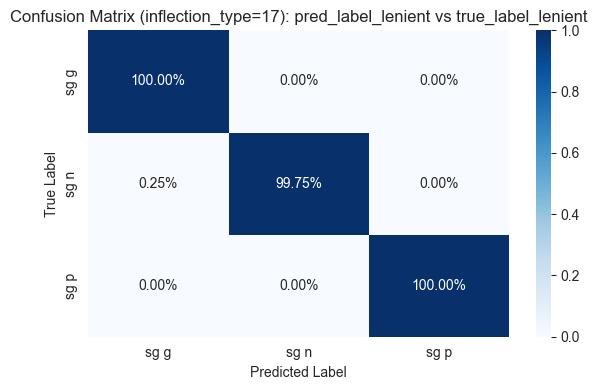

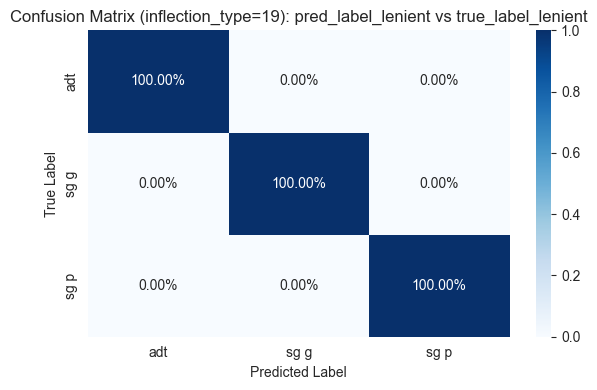

In [34]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

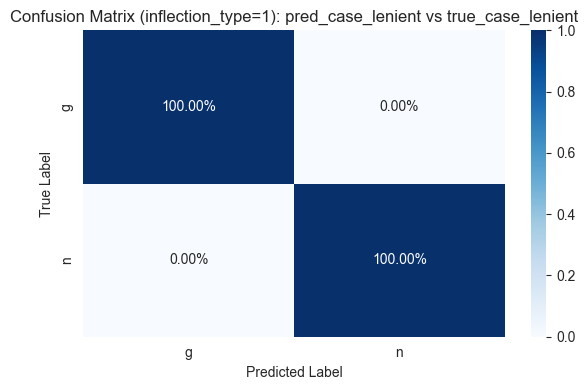

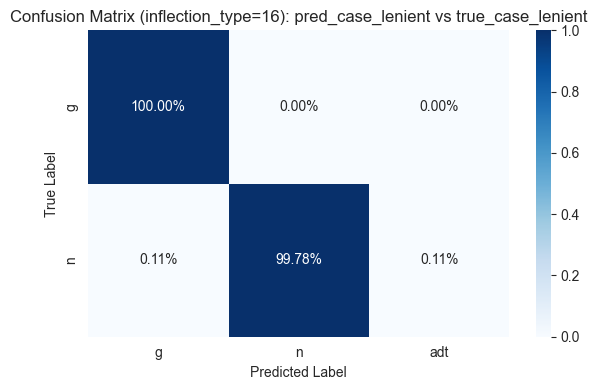

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1970


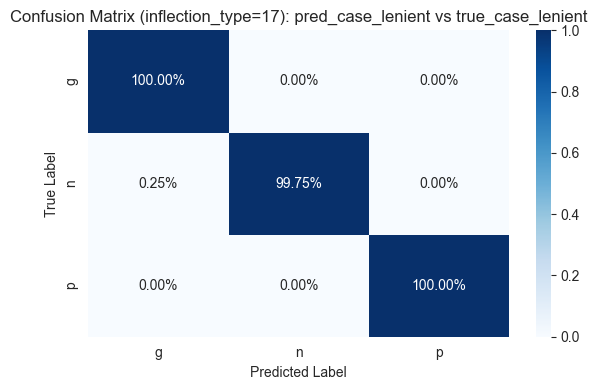

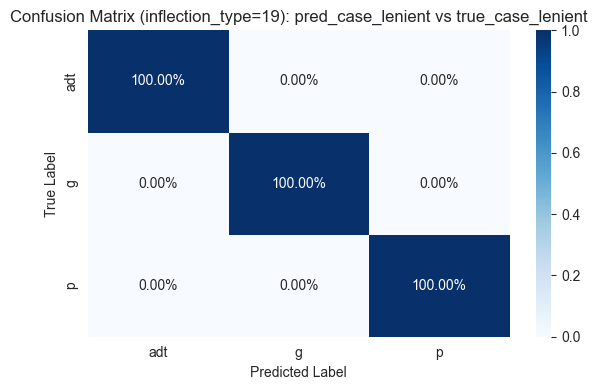

In [35]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

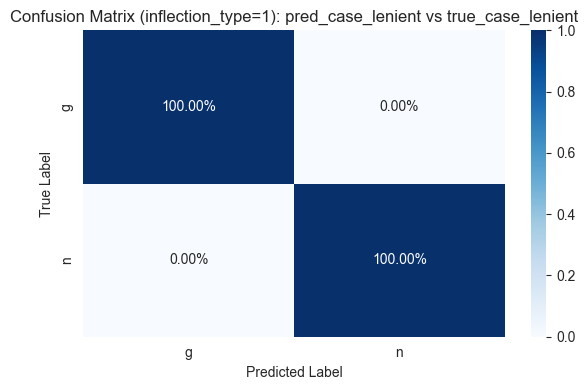

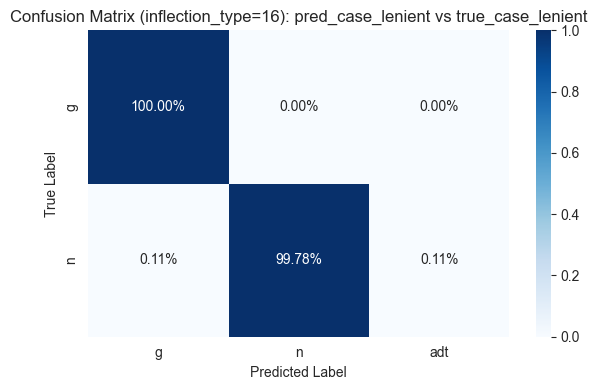

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1970


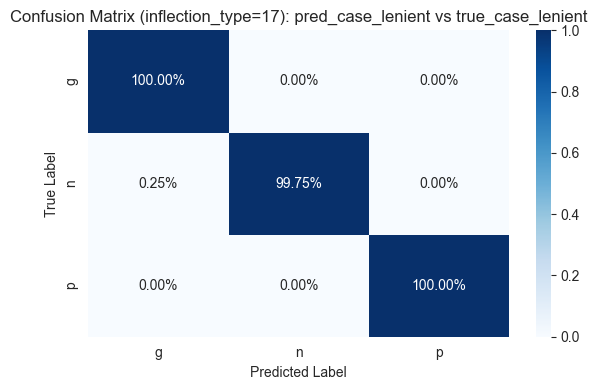

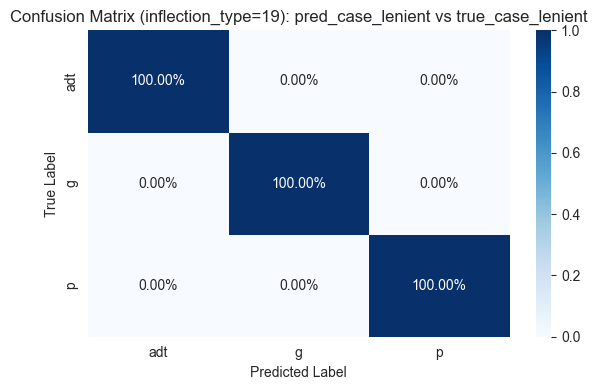

In [36]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

## END
